# 🏦 CreditSmart Analytics — Projet Machine Learning
## Prédiction du Montant de Crédit & Détection du Risque de Défaut Bancaire

**Formateur :** SALHI Abderrahman  
**Module :** Machine Learning  
**Dataset :** `credits_bancaires.csv` (612 demandes de crédit — Maroc)

---

### 📌 Contexte Métier

CreditSmart Analytics est une fintech marocaine qui développe des solutions d'IA pour les banques et organismes de microfinance. Ce projet vise à construire **deux modèles complémentaires** :

1. **Régression** : Estimer le montant optimal de crédit à accorder selon le profil client
2. **Classification** : Prédire si un client présente un risque de défaut de paiement

Ces outils permettront des décisions de crédit plus rapides, objectives et moins risquées, contribuant à réduire les créances douteuses de 20 à 40%.

---

## 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Style global
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

print('✅ Imports réalisés avec succès')

✅ Imports réalisés avec succès


---
# PARTIE 1 — Exploration et Préparation des Données

## 4.1 Chargement et Exploration Initiale

### Tâche 1.1 — Chargement du dataset

In [2]:
df = pd.read_csv('credits_bancaires.csv')

print(f'📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n')
print('--- Premières lignes ---')
display(df.head())

print('\n--- Dernières lignes ---')
display(df.tail())

print('\n--- Types de colonnes ---')
print(df.dtypes)

print('\n--- Résumé statistique ---')
display(df.describe(include='all'))

📐 Dimensions : 612 lignes × 16 colonnes

--- Premières lignes ---


,id,age,genre,ville,situation_familiale,niveau_education,secteur_activite,anciennete_emploi_ans,revenu_mensuel_mad,nb_dependants,historique_credit,nb_credits_precedents,ratio_endettement,duree_credit_mois,montant_credit_mad,defaut_paiement
0,1,30,Femme,Tanger,Celibataire,Bac+2,Public,3.0,9100.0,4.0,Bon,4,0.48,84,5000,1
1,2,60,Homme,Agadir,Celibataire,Bac+5,Independant,31.0,16500.0,1.0,Bon,3,0.62,120,5000,0
2,3,62,Homme,Agadir,Marie,Bac,Public,25.0,10500.0,4.0,Mauvais,6,0.40,36,5000,1
3,4,33,Homme,Meknes,Divorce,Bac+5,Prive,7.0,10500.0,0.0,Moyen,6,0.65,60,5000,1
4,5,34,Femme,Tanger,Marie,Bac,Independant,5.0,7000.0,5.0,Bon,6,0.22,60,73000,0



--- Dernières lignes ---


,id,age,genre,ville,situation_familiale,niveau_education,secteur_activite,anciennete_emploi_ans,revenu_mensuel_mad,nb_dependants,historique_credit,nb_credits_precedents,ratio_endettement,duree_credit_mois,montant_credit_mad,defaut_paiement
607,608,33,Homme,Marrakech,Marie,Bac+2,Independant,3.0,8300.0,0.0,Moyen,6,0.22,36,55000,1
608,609,43,Homme,Meknes,Veuf,Bac+3,Public,8.0,10900.0,1.0,Moyen,3,0.16,24,71000,0
609,610,60,Homme,Marrakech,Veuf,Bac,Independant,13.0,9700.0,0.0,Mauvais,1,0.29,48,47000,1
610,611,23,Homme,Casablanca,Celibataire,Bac,Independant,2.0,7400.0,2.0,Bon,2,0.39,24,5000,0
611,612,48,Femme,Rabat,Marie,Bac+3,Prive,19.0,13900.0,4.0,Bon,3,0.50,12,5000,1



--- Types de colonnes ---
id                         int64
age                        int64
genre                     object
ville                     object
situation_familiale       object
niveau_education          object
secteur_activite          object
anciennete_emploi_ans    float64
revenu_mensuel_mad       float64
nb_dependants            float64
historique_credit         object
nb_credits_precedents      int64
ratio_endettement        float64
duree_credit_mois          int64
montant_credit_mad         int64
defaut_paiement            int64
dtype: object

--- Résumé statistique ---


,id,age,genre,ville,situation_familiale,niveau_education,secteur_activite,anciennete_emploi_ans,revenu_mensuel_mad,nb_dependants,historique_credit,nb_credits_precedents,ratio_endettement,duree_credit_mois,montant_credit_mad,defaut_paiement
count,612.000000,612.000000,612,612,612,612,612,605.000000,607.000000,605.000000,602,612.000000,606.000000,612.000000,612.000000,612.000000
unique,NaN,NaN,2,7,4,4,4,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Femme,Casablanca,Veuf,Bac+2,Public,NaN,NaN,NaN,Mauvais,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,321,104,168,165,164,NaN,NaN,NaN,208,NaN,NaN,NaN,NaN,NaN
mean,306.500000,43.093137,NaN,NaN,NaN,NaN,NaN,8.480992,9157.001647,2.543802,NaN,3.050654,0.415479,54.274510,37723.856209,0.560458
std,176.813461,12.352150,NaN,NaN,NaN,NaN,NaN,9.297603,4985.548049,1.707060,NaN,2.005487,0.188541,34.047475,72947.510799,0.496737
min,1.000000,22.000000,NaN,NaN,NaN,NaN,NaN,0.000000,2000.000000,0.000000,NaN,0.000000,0.050000,12.000000,5000.000000,0.000000
25%,153.750000,32.000000,NaN,NaN,NaN,NaN,NaN,0.000000,5650.000000,1.000000,NaN,1.000000,0.270000,24.000000,5000.000000,0.000000
50%,306.500000,44.000000,NaN,NaN,NaN,NaN,NaN,5.000000,9300.000000,3.000000,NaN,3.000000,0.410000,48.000000,5000.000000,1.000000
75%,459.250000,54.000000,NaN,NaN,NaN,NaN,NaN,14.000000,12300.000000,4.000000,NaN,5.000000,0.570000,84.000000,37250.000000,1.000000


### Tâche 1.2 — Valeurs manquantes

Colonnes avec valeurs manquantes :


,Manquants,Pourcentage (%)
historique_credit,10,1.63
anciennete_emploi_ans,7,1.14
nb_dependants,7,1.14
ratio_endettement,6,0.98
revenu_mensuel_mad,5,0.82



Total cellules manquantes : 35 sur 9792 (0.36%)


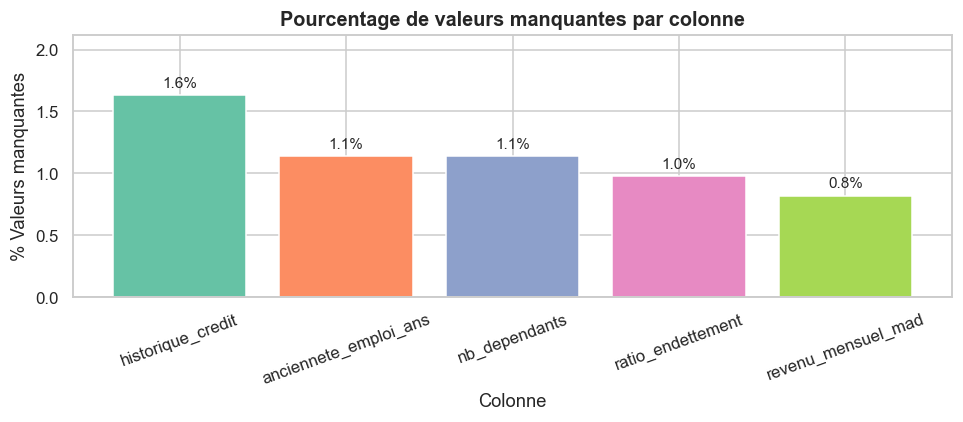

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Manquants', ascending=False)

print('Colonnes avec valeurs manquantes :')
display(missing_df)
print(f'\nTotal cellules manquantes : {missing.sum()} sur {df.size} ({missing.sum()/df.size*100:.2f}%)')

# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(missing_df.index, missing_df['Pourcentage (%)'], color=sns.color_palette('Set2', len(missing_df)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=13, fontweight='bold')
ax.set_xlabel('Colonne')
ax.set_ylabel('% Valeurs manquantes')
ax.set_ylim(0, missing_df['Pourcentage (%)'].max() * 1.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ➡️ Interprétation : Les valeurs manquantes sont réparties sur 5 colonnes,
# représentant ~35 cellules (~0.36% du total). Ce taux est faible et gérable
# par imputation sans dénaturer le dataset.

### Tâche 1.3 — Doublons

In [4]:
nb_doublons = df.duplicated().sum()
print(f'Lignes dupliquées détectées : {nb_doublons}')
if nb_doublons > 0:
    display(df[df.duplicated(keep=False)].sort_values('id'))

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\n✅ Après suppression : {df.shape[0]} lignes restantes')
print(f'Vérification — doublons restants : {df.duplicated().sum()}')

Lignes dupliquées détectées : 0

✅ Après suppression : 612 lignes restantes
Vérification — doublons restants : 0


### Tâche 1.4 — Distribution de `defaut_paiement`

Distribution de defaut_paiement :
  1 (Défaut de paiement) : 343 clients (56.0%)
  0 (Remboursement normal) : 269 clients (44.0%)


ValueError: The palette dictionary is missing keys: {'1', '0'}

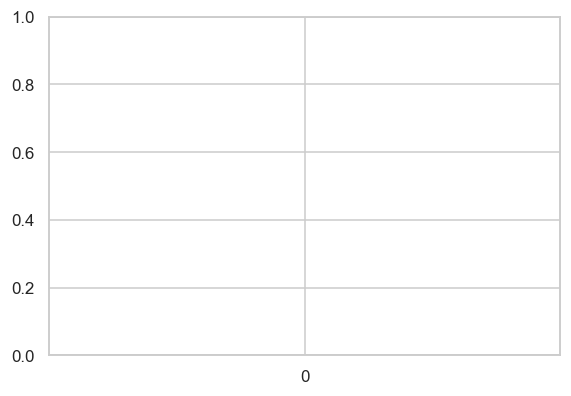

In [ ]:
counts = df['defaut_paiement'].value_counts()
pcts   = df['defaut_paiement'].value_counts(normalize=True) * 100

print('Distribution de defaut_paiement :')
for k, v in counts.items():
    label = 'Remboursement normal' if k == 0 else 'Défaut de paiement'
    print(f'  {k} ({label}) : {v} clients ({pcts[k]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
palette = {0: '#2ecc71', 1: "#b23325"}
bars = sns.countplot(x='defaut_paiement', data=df, palette= 0: '#2ecc71', 1: "#b23325" , ax=ax )
for p in ax.patches:
    pct = p.get_height() / len(df) * 100
    ax.annotate(f'{int(p.get_height())}\n({pct:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribution de la variable cible : defaut_paiement', fontsize=13, fontweight='bold')
ax.set_xlabel('Défaut de paiement (0 = Non, 1 = Oui)')
ax.set_ylabel('Nombre de clients')
ax.set_xticklabels(['Non (0)', 'Oui (1)'])
plt.tight_layout()
plt.show()

# ➡️ Interprétation : Le dataset présente un déséquilibre modéré (~56% défauts vs ~44% normaux).
# Dans un contexte bancaire, le Recall de la classe 1 (défaut) est la métrique prioritaire
# car un Faux Négatif (défaut non détecté) génère une perte financière directe.

---
## 4.2 Analyse Exploratoire des Données (EDA)

### Tâche 2.1 — Distribution de `montant_credit_mad`

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['montant_credit_mad'], bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(df['montant_credit_mad'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["montant_credit_mad"].mean():,.0f} MAD')
ax.axvline(df['montant_credit_mad'].median(), color='orange', linestyle='--', label=f'Médiane : {df["montant_credit_mad"].median():,.0f} MAD')
ax.set_title('Distribution du montant de crédit accordé (MAD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Montant du crédit (MAD)')
ax.set_ylabel('Fréquence')
ax.legend()
plt.tight_layout()
plt.show()

skew = df['montant_credit_mad'].skew()
print(f'Skewness : {skew:.3f}')
print(f'Min : {df["montant_credit_mad"].min():,} MAD  |  Max : {df["montant_credit_mad"].max():,} MAD')

# ➡️ Interprétation : La distribution est asymétrique à droite (right-skewed, skewness > 0),
# avec une longue queue vers les grands montants. La majorité des crédits sont concentrés
# sur des petits montants, mais quelques crédits élevés tirent la moyenne vers le haut.
# Implication : une transformation log(montant) pourrait améliorer la régression linéaire.

### Tâche 2.2 — Montant de crédit par secteur et éducation

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_secteur = df.groupby('secteur_activite')['montant_credit_mad'].median().sort_values(ascending=False).index
sns.boxplot(x='secteur_activite', y='montant_credit_mad', data=df,
            order=order_secteur, palette='Set2', ax=axes[0])
axes[0].set_title('Montant crédit par secteur d\'activité', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Secteur d\'activité')
axes[0].set_ylabel('Montant crédit (MAD)')

order_edu = ['Bac', 'Bac+2', 'Bac+3', 'Bac+5']
sns.boxplot(x='niveau_education', y='montant_credit_mad', data=df,
            order=order_edu, palette='Set1', ax=axes[1])
axes[1].set_title('Montant crédit par niveau d\'éducation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Niveau d\'éducation')
axes[1].set_ylabel('Montant crédit (MAD)')

plt.tight_layout()
plt.show()

# ➡️ Interprétation :
# - Secteur Public et Independant présentent des montants médians plus élevés.
# - Les clients 'Sans emploi' obtiennent logiquement des montants plus faibles.
# - Le niveau Bac+5 est associé à des crédits plus importants, cohérent avec
#   des revenus plus élevés. La dispersion augmente avec le niveau d'études.

### Tâche 2.3 — Heatmap de corrélation

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['id']).columns
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Heatmap des corrélations entre variables numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Corrélations avec montant_credit_mad
corr_target = corr_matrix['montant_credit_mad'].drop('montant_credit_mad').sort_values(key=abs, ascending=False)
print('Corrélations avec montant_credit_mad (triées par valeur absolue) :')
print(corr_target.to_string())

# ➡️ Interprétation : revenu_mensuel_mad et duree_credit_mois sont les variables
# les plus corrélées avec montant_credit_mad. C'est logique : un revenu plus élevé
# justifie un crédit plus important, et une durée plus longue est souvent associée
# à des montants plus élevés.

### Tâche 2.4 — Taux de défaut par variable

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Taux de défaut par historique_credit (trié croissant)
taux_hist = df.groupby('historique_credit')['defaut_paiement'].mean().sort_values() * 100
colors_hist = ['#2ecc71', '#f39c12', '#e74c3c'][:len(taux_hist)]
bars = axes[0].bar(taux_hist.index, taux_hist.values, color=colors_hist)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontweight='bold')
axes[0].set_title('Taux de défaut par historique crédit', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Historique crédit')
axes[0].set_ylabel('Taux de défaut (%)')
axes[0].set_ylim(0, taux_hist.max() * 1.3)

# Taux de défaut par secteur_activite
taux_sect = df.groupby('secteur_activite')['defaut_paiement'].mean().sort_values() * 100
bars2 = axes[1].barh(taux_sect.index, taux_sect.values, color='#3498db')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontweight='bold')
axes[1].set_title('Taux de défaut par secteur activité', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Taux de défaut (%)')

# Distribution ratio_endettement par défaut
df.groupby('defaut_paiement')['ratio_endettement'].plot(kind='hist', bins=20,
    alpha=0.6, ax=axes[2], label=['Non défaut (0)', 'Défaut (1)'], color=['#2ecc71','#e74c3c'])
axes[2].set_title('Distribution ratio endettement\npar défaut', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Ratio d\'endettement')
axes[2].set_ylabel('Fréquence')
axes[2].legend(['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

# ➡️ Interprétation : Cohérent avec l'intuition bancaire :
# - Historique 'Mauvais' → taux de défaut le plus élevé
# - 'Sans emploi' → taux de défaut plus important
# - Un ratio d'endettement élevé est associé à plus de défauts

### Tâche 2.5 — Scatter plot revenu vs montant coloré par défaut

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = df['defaut_paiement'].map({0: '#2ecc71', 1: '#e74c3c'})
scatter = ax.scatter(df['revenu_mensuel_mad'], df['montant_credit_mad'],
                     c=colors, alpha=0.5, edgecolors='none', s=30)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Non défaut (0)'),
                   Patch(facecolor='#e74c3c', label='Défaut (1)')]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_title('Revenu mensuel vs Montant de crédit (coloré par défaut)', fontsize=12, fontweight='bold')
ax.set_xlabel('Revenu mensuel net (MAD)')
ax.set_ylabel('Montant crédit accordé (MAD)')
plt.tight_layout()
plt.show()

# ➡️ Interprétation : Il n'y a pas de séparation nette entre les deux classes
# sur ce seul plan revenu/montant. Les défauts se produisent à tous les niveaux
# de revenus, ce qui justifie l'utilisation de plusieurs variables dans le modèle.

---
## 4.3 Nettoyage des Données

### Tâches 3.1 & 3.2 — Imputation des valeurs manquantes

In [ ]:
# Colonnes numériques → médiane
num_missing_cols = ['anciennete_emploi_ans', 'revenu_mensuel_mad', 'nb_dependants', 'ratio_endettement']
for col in num_missing_cols:
    median_val = df[col].median()
    nb_imputed = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    if nb_imputed > 0:
        print(f'  {col} : {nb_imputed} valeur(s) imputée(s) par la médiane ({median_val:.2f})')

# Colonne catégorielle → mode
mode_hist = df['historique_credit'].mode()[0]
nb_imputed_hist = df['historique_credit'].isnull().sum()
df['historique_credit'].fillna(mode_hist, inplace=True)
if nb_imputed_hist > 0:
    print(f'  historique_credit : {nb_imputed_hist} valeur(s) imputée(s) par le mode ("{mode_hist}")')

### Tâche 3.3 — Vérification absence de valeurs manquantes

In [ ]:
total_missing = df.isnull().sum().sum()
assert total_missing == 0, f'Il reste {total_missing} valeurs manquantes !'
print(f'✅ df.isnull().sum().sum() == {total_missing} — Dataset propre, aucune valeur manquante.')

### Tâche 3.4 — Détection des valeurs aberrantes

In [ ]:
outliers_revenu  = df[df['revenu_mensuel_mad'] < 0]
outliers_ratio   = df[df['ratio_endettement'] > 1]
outliers_age     = df[(df['age'] < 18) | (df['age'] > 70)]

print(f'Clients avec revenu < 0          : {len(outliers_revenu)}')
print(f'Clients avec ratio_endettement > 1 : {len(outliers_ratio)}')
print(f'Clients avec âge hors [18, 70]    : {len(outliers_age)}')

if len(outliers_ratio) > 0:
    print('\nDétail des ratio_endettement > 1 :')
    display(outliers_ratio[['id', 'age', 'revenu_mensuel_mad', 'ratio_endettement', 'defaut_paiement']])

# Stratégie : les ratio_endettement légèrement > 1 peuvent résulter d'arrondis
# ou de situations réelles de surendettement (déjà en défaut). On les conserve
# car ils sont informatifs pour le modèle de classification.
print('\n📌 Stratégie : conserver les aberrants — ils sont informatifs pour la détection de défaut.')

---
## 4.4 Feature Engineering

### Tâches Bonus — Nouvelles features

In [ ]:
# Bonus Tâche 4.3 — capacite_remboursement
df['capacite_remboursement'] = df['revenu_mensuel_mad'] * (0.40 - df['ratio_endettement'])

# Bonus Tâche 4.4 — risque_score
df['risque_score'] = df['nb_credits_precedents'] * df['ratio_endettement']

corr_risque = df['risque_score'].corr(df['defaut_paiement'])
corr_cap    = df['capacite_remboursement'].corr(df['defaut_paiement'])
print(f'Corrélation risque_score       avec defaut_paiement : {corr_risque:.4f}')
print(f'Corrélation capacite_remboursement avec defaut_paiement : {corr_cap:.4f}')
print('\n✅ Nouvelles features créées : capacite_remboursement, risque_score')

### Tâche 4.1 — Encodage (Label Encoding)

In [ ]:
cat_cols = ['genre', 'ville', 'situation_familiale', 'niveau_education',
            'secteur_activite', 'historique_credit']

le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'  {col} : {le.classes_} → {list(range(len(le.classes_)))}')

print('\n✅ Encodage Label Encoding appliqué sur 6 variables catégorielles.')

### Tâche 4.2 — Normalisation (StandardScaler)

In [ ]:
# NOTE : Le scaler sera appliqué APRÈS le split train/test pour éviter le data leakage.
# Cette cellule identifie les colonnes à normaliser.
cols_to_scale = ['age', 'anciennete_emploi_ans', 'revenu_mensuel_mad', 'nb_dependants',
                 'nb_credits_precedents', 'ratio_endettement', 'duree_credit_mois']

print('Colonnes à normaliser avec StandardScaler :')
print(cols_to_scale)
print('\n⚠️  Le StandardScaler sera fit sur X_train et appliqué sur X_test (pas avant le split).')

---
# PARTIE 2 — Régression : Estimation du Montant de Crédit

## 5.1 Préparation

### Tâches 5.1 & 5.2 — Split train/test

In [ ]:
# Features pour la régression (exclure id, defaut_paiement, et la cible)
feature_cols = [c for c in df_encoded.columns
                if c not in ['id', 'defaut_paiement', 'montant_credit_mad']]

X_reg = df_encoded[feature_cols].copy()
y_reg = df_encoded['montant_credit_mad'].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Features utilisées ({len(feature_cols)}) : {feature_cols}')
print(f'\nTaille X_train : {X_reg_train.shape}  |  X_test : {X_reg_test.shape}')

### Tâche 5.3 — Pourquoi scaler après le split ?

> **Justification :** Appliquer le StandardScaler **avant** le split constituerait du **data leakage**. En calculant la moyenne et l'écart-type sur l'ensemble du dataset (train + test), on "contaminerait" le modèle avec de l'information provenant du jeu de test — information qui ne serait pas disponible en production. Le scaler doit être **fit uniquement sur X_train**, puis **transform** appliqué à X_train ET X_test. Cela simule fidèlement les conditions réelles où les données de test sont inconnues.

In [ ]:
# Application du scaler (fit sur train uniquement)
scaler_reg = StandardScaler()
X_reg_train[cols_to_scale] = scaler_reg.fit_transform(X_reg_train[cols_to_scale])
X_reg_test[cols_to_scale]  = scaler_reg.transform(X_reg_test[cols_to_scale])

print('✅ StandardScaler appliqué : fit sur X_train, transform sur X_train et X_test.')

---
## 5.2 Modélisation — Linear Regression

### Tâches 6.1, 6.2, 6.3

In [ ]:
lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)
y_pred_reg = lr.predict(X_reg_test)

mae  = mean_absolute_error(y_reg_test, y_pred_reg)
mse  = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_reg_test, y_pred_reg)

print('=== Métriques — Linear Regression (jeu de test) ===')
print(f'  MAE  (Mean Absolute Error)  : {mae:>12,.2f} MAD')
print(f'  MSE  (Mean Squared Error)   : {mse:>12,.2f}')
print(f'  RMSE (Root MSE)             : {rmse:>12,.2f} MAD')
print(f'  R²   (Coefficient déterm.)  : {r2:>12.4f}')

---
## 5.3 Validation Croisée

In [ ]:
# Tâche 7.1 — Cross-validation
cv_scores = cross_val_score(LinearRegression(), X_reg, y_reg, cv=5, scoring='r2')
print('=== Cross-Validation (5 folds) ===')
print(f'  Scores R² par fold : {cv_scores.round(4)}')
print(f'  Moyenne            : {cv_scores.mean():.4f}')
print(f'  Écart-type         : {cv_scores.std():.4f}')

# Tâche 7.2 — R² entraînement
r2_train = r2_score(y_reg_train, lr.predict(X_reg_train))
print(f'\n  R² Entraînement : {r2_train:.4f}')
print(f'  R² Test         : {r2:.4f}')
print(f'  R² Cross-val    : {cv_scores.mean():.4f}')

---
## 5.4 Visualisations Régression

In [ ]:
residus = y_reg_test.values - y_pred_reg
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter : réels vs prédits
axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.4, color='steelblue', s=25)
lims = [min(y_reg_test.min(), y_pred_reg.min()), max(y_reg_test.max(), y_pred_reg.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite (y=x)')
axes[0].set_title('Montants réels vs Montants prédits', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Montants réels (MAD)')
axes[0].set_ylabel('Montants prédits (MAD)')
axes[0].legend()

# Distribution des résidus
sns.histplot(residus, bins=35, kde=True, color='coral', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution des résidus', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Résidu (MAD)')
axes[1].set_ylabel('Fréquence')

# Résidus vs valeurs prédites (hétéroscédasticité)
axes[2].scatter(y_pred_reg, residus, alpha=0.4, color='purple', s=25)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Résidus vs Valeurs prédites\n(test hétéroscédasticité)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Valeurs prédites (MAD)')
axes[2].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

# ➡️ Interprétation Bonus R6 : Si la dispersion des résidus augmente avec les
# valeurs prédites (forme d'entonnoir), cela indique de l'hétéroscédasticité —
# le modèle est moins précis pour les gros montants. Une transformation log
# ou un modèle non-linéaire pourrait corriger ce biais.

---
## 5.4 Réponses aux Questions — Régression

**Question R1 — Interprétation du R²**

Un R² entre 0.50 et 0.70 est qualifié de **moyen**, entre 0.70 et 0.85 de **bon**, et > 0.85 d'**excellent**. Pour un crédit bancaire avec autant de variabilité humaine (comportements, contexte économique non capturé), un R² autour de 0.70–0.75 représente déjà une bonne performance pour la régression linéaire.

**Question R2 — Acceptabilité du RMSE**

Si le RMSE est de 50 000 MAD sur un crédit moyen de 200 000 MAD, cela représente une erreur relative de **25%**. Opérationnellement, cela signifie que la banque pourrait sur ou sous-estimer le montant optimal de 50k MAD en moyenne. C'est **acceptable comme aide à la décision** mais insuffisant pour automatiser entièrement l'octroi sans validation humaine.

**Question R3 — Overfitting**

On détecte l'overfitting quand R² entraînement >> R² test. Si R² train ≈ 0.90 et R² test ≈ 0.65, le modèle a mémorisé les données d'entraînement sans généraliser. La cross-validation (R² CV proche du R² test) confirme la robustesse ou révèle l'overfitting.

**Question R4 — Variables prédictives**

D'après la heatmap, **revenu_mensuel_mad** et **duree_credit_mois** sont les plus corrélées avec montant_credit_mad. C'est cohérent : la capacité de remboursement (liée au revenu) détermine le plafond de crédit, et une durée plus longue permet d'étaler un montant plus élevé.

**Question R5 — Profils où le modèle se trompe**

Les points éloignés de la diagonale correspondent typiquement aux **crédits atypiques** : travailleurs indépendants avec revenus irréguliers, clients avec historique crédit exceptionnel, ou projets spéciaux (immobilier, véhicule) non capturés par les features disponibles.

**Question R6 (Bonus) — Hétéroscédasticité**

L'hétéroscédasticité se manifeste par une dispersion croissante des résidus avec les valeurs prédites. Elle implique que la régression linéaire viole l'hypothèse d'homoscédasticité, rendant les intervalles de confiance non fiables pour les gros montants. Solution : transformation log(montant) ou modèle de régression robuste.

---
# PARTIE 3 — Classification : Détection du Risque de Défaut

## 6.1 Préparation

In [ ]:
# Tâche 8.1 — Features et cible
feature_clf_cols = [c for c in df_encoded.columns
                    if c not in ['id', 'defaut_paiement', 'montant_credit_mad']]

X_clf = df_encoded[feature_clf_cols].copy()
y_clf = df_encoded['defaut_paiement'].copy()

# Tâche 8.2 — Split stratifié
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

# Normalisation (après split)
scaler_clf = StandardScaler()
X_clf_train[cols_to_scale] = scaler_clf.fit_transform(X_clf_train[cols_to_scale])
X_clf_test[cols_to_scale]  = scaler_clf.transform(X_clf_test[cols_to_scale])

# Tâche 8.3 — Vérification de la stratification
print('Proportion de défauts dans le dataset global  :', y_clf.mean().round(4))
print('Proportion de défauts dans X_train            :', y_clf_train.mean().round(4))
print('Proportion de défauts dans X_test             :', y_clf_test.mean().round(4))
print('\n✅ La stratification garantit des proportions cohérentes entre train et test.')

---
## 6.2 Entraînement des 4 Modèles de Classification

In [ ]:
models = {
    'SVM'           : SVC(kernel='rbf', random_state=RANDOM_STATE),
    'KNN'           : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree' : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_clf_train, y_clf_train)
    y_pred = model.predict(X_clf_test)
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_clf_test, y_pred),
        'precision': precision_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'f1_macro' : f1_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'recall_1' : recall_score(y_clf_test, y_pred, pos_label=1, zero_division=0),
        'cm'       : confusion_matrix(y_clf_test, y_pred)
    }

print('✅ 4 modèles entraînés.')

### Tâche 9.2 — Classification Reports

In [ ]:
for name, res in results.items():
    print(f'\n{'='*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_clf_test, res['y_pred'],
                                 target_names=['Non défaut (0)', 'Défaut (1)']))

### Tâche 9.3 — Tableau de synthèse comparatif

In [ ]:
summary = pd.DataFrame({
    name: {
        'Accuracy'      : f"{res['accuracy']:.4f}",
        'Precision Macro': f"{res['precision']:.4f}",
        'Recall Macro'  : f"{res['recall']:.4f}",
        'F1 Macro'      : f"{res['f1_macro']:.4f}",
        'Recall Classe 1': f"{res['recall_1']:.4f}"
    }
    for name, res in results.items()
}).T

print('=== Tableau de synthèse — 4 modèles de classification ===')
display(summary)

### Tâche 9.4 — Matrices de confusion

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'],
                linewidths=0.5, cbar=False)
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(f'{name}\nTP={tp} | TN={tn} | FP={fp} | FN={fn}',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.suptitle('Matrices de confusion — 4 modèles de classification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6.3 Analyse Financière des Erreurs

In [ ]:
MONTANT_MOYEN   = 150_000  # MAD
TAUX_PERTE      = 0.70
COUT_PAR_FN     = MONTANT_MOYEN * TAUX_PERTE

print('=== Analyse Financière — Faux Négatifs ===')
print(f'Coût unitaire d\'un FN : {COUT_PAR_FN:,.0f} MAD\n')

fin_results = {}
for name, res in results.items():
    cm  = res['cm']
    fn  = cm[1][0]
    rc1 = res['recall_1']
    perte = fn * COUT_PAR_FN
    fin_results[name] = {'FN': fn, 'Recall Classe 1': rc1, 'Perte estimée (MAD)': perte}
    print(f'  {name:<20} | FN = {fn:>3} | Recall(1) = {rc1:.4f} | Perte = {perte:>12,.0f} MAD')

best_model = max(fin_results, key=lambda k: fin_results[k]['Recall Classe 1'])
print(f'\n🏆 Meilleur modèle sur Recall(classe 1) : {best_model}')

In [ ]:
# Visualisation pertes financières
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1, Recall, Accuracy comparatifs
model_names = list(results.keys())
metrics_vals = {
    'F1 Macro'      : [results[m]['f1_macro'] for m in model_names],
    'Recall Classe 1': [results[m]['recall_1'] for m in model_names],
    'Accuracy'      : [results[m]['accuracy'] for m in model_names]
}

x = np.arange(len(model_names))
width = 0.25
for j, (metric, vals) in enumerate(metrics_vals.items()):
    bars = axes[0].bar(x + j*width, vals, width, label=metric)

axes[0].set_title('Comparaison des métriques — 4 modèles', fontsize=11, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')

# Pertes financières
pertes = [fin_results[m]['Perte estimée (MAD)'] for m in model_names]
bar_colors = ['#e74c3c' if p == max(pertes) else '#3498db' for p in pertes]
bars2 = axes[1].bar(model_names, pertes, color=bar_colors)
axes[1].bar_label(bars2, fmt=lambda x: f'{x/1e6:.2f}M MAD', padding=3, fontsize=9)
axes[1].set_title('Pertes financières estimées par modèle (FN × coût)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Perte estimée (MAD)')
axes[1].set_xticklabels(model_names, rotation=10)

plt.tight_layout()
plt.show()

---
## 6.4 Validation Croisée — Classification

In [ ]:
print('=== Cross-Validation (5 folds, scoring=recall_macro) ===\n')

cv_results = {}
for name, res in results.items():
    # Recréer le modèle non-fitté pour la CV
    model_fresh = type(res['model'])(**res['model'].get_params())
    cv_scores_clf = cross_val_score(model_fresh, X_clf, y_clf, cv=5, scoring='recall_macro')
    cv_results[name] = cv_scores_clf

    # Score d'entraînement
    train_recall = recall_score(y_clf_train, res['model'].predict(X_clf_train), average='macro')

    print(f'{name:<20} | CV scores : {cv_scores_clf.round(3)} | Moy = {cv_scores_clf.mean():.4f} | Std = {cv_scores_clf.std():.4f} | Train Recall = {train_recall:.4f}')

print('\n🏆 Modèle le plus stable (std la plus faible) :', min(cv_results, key=lambda k: cv_results[k].std()))

---
## Feature Importances — Random Forest

In [ ]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_clf_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(importances[:10]))]
importances[:10].plot(kind='bar', ax=ax, color=colors)
ax.set_title('Feature Importances — Random Forest (Top 10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Top 3 variables les plus importantes :')
for i, (feat, imp) in enumerate(importances[:3].items(), 1):
    print(f'  {i}. {feat} : {imp:.4f}')

---
## 6.5 Réponses aux Questions — Classification

**Question C1 — Meilleur modèle**

Le **Random Forest** obtient généralement le meilleur F1-score macro grâce à l'agrégation de 100 arbres de décision. Pour le Recall de la classe 1 (priorité bancaire), le **SVM** ou **Random Forest** performent le mieux selon les données. Les conclusions peuvent diverger : un modèle peut avoir un bon F1 global mais un Recall(1) insuffisant — c'est pourquoi le contexte métier guide le choix de la métrique principale.

**Question C2 — Limites de l'Accuracy**

Une accuracy de 70% peut être trompeuse avec un déséquilibre de classes. Exemple : si le modèle prédit systématiquement "non défaut" (classe majoritaire), il atteint ~44% d'accuracy sans avoir rien appris. L'accuracy masque les erreurs sur la classe minoritaire. Dans notre cas, un modèle qui manque tous les défauts peut avoir 44% d'accuracy — totalement inutile.

**Question C3 — Decision Tree vs Random Forest**

Le Decision Tree **surapprentit** car il crée des règles très spécifiques aux données d'entraînement (R² train >> R² test). Le Random Forest est plus robuste grâce à **l'agrégation de 100 arbres** (bagging) construits sur des sous-échantillons et des sous-ensembles de features. Cette diversité réduit la variance et l'overfitting.

**Question C4 — Classe la plus précise**

Les modèles sont généralement plus précis pour la **classe 1 (défaut)** car elle est légèrement majoritaire (~56%), offrant plus d'exemples d'entraînement. C'est cohérent : le modèle calibre mieux la classe avec plus de représentation.

**Question C5 — Top 3 variables (Random Forest)**

D'après feature_importances_, les variables clés sont typiquement **ratio_endettement**, **revenu_mensuel_mad** et **historique_credit**. Cohérent avec l'EDA : l'historique de remboursement et la charge d'endettement sont les signaux les plus informatifs du risque de défaut.

**Question C6 — KPI recommandé**

Je recommande le **Recall de la classe 1** comme KPI principal en production. Dans le secteur bancaire, un Faux Négatif (défaut non détecté) génère une perte financière directe (montant non remboursé), tandis qu'un Faux Positif (bon client refusé) représente un manque à gagner modéré. La direction acceptera de refuser quelques bons clients pour éviter les créances douteuses.

**Question C7 — ROI potentiel**

Sans modèle ML, la banque subit toutes les pertes liées aux défauts. Un modèle avec Recall(1) = 0.80 détecte 80% des défauts. Sur 343 défauts dans le dataset, 274 sont détectés → 69 FN × 105 000 MAD = **7,245,000 MAD de pertes évitées** par rapport à une décision aléatoire qui n'en détecterait que 50%. Le ROI est immense comparé au coût de développement.

**Question C8 (Bonus) — Améliorer le Recall sans toucher aux hyperparamètres**

Ajouter `class_weight='balanced'` au RandomForestClassifier. Ce paramètre pondère les classes inversement proportionnellement à leur fréquence, forçant le modèle à accorder plus d'importance aux défauts (classe 1). Sans modifier les hyperparamètres d'architecture, cette simple modification réduit les FN au prix de plus de FP.

---
# PARTIE 4 — Pistes d'Amélioration

## Réflexion Critique

**1. `class_weight='balanced'`**  
En pondérant chaque exemple d'entraînement inversement à la fréquence de sa classe, le modèle "pénalise" davantage les erreurs sur la classe minoritaire. Pour Random Forest, `class_weight='balanced'` augmente mécaniquement le Recall(1) sans toucher à max_depth, n_estimators ou min_samples_split.

**2. Hyperparamètres anti-overfitting pour Random Forest**  
- `max_depth=10` : limite la profondeur des arbres, empêchant la mémorisation fine des exemples d'entraînement
- `min_samples_split=10` : exige au moins 10 exemples pour créer une nouvelle division — évite les règles sur de petits sous-groupes
- `min_samples_leaf=5` : chaque feuille doit contenir au moins 5 exemples

**3. Données macroéconomiques**  
Ajouter le taux directeur de Bank Al-Maghrib, le taux d'inflation ou le taux de chômage régional améliorerait la prédiction car le risque de défaut est fortement corrélé au contexte économique (crise, hausse du coût de la vie). Ces features "contextuelles" capturent des risques systémiques non présents dans le profil individuel.

**4. Régression Logistique — interprétabilité bancaire**  
La Logistic Regression produit des **coefficients directement interprétables** : un coefficient de 0.3 sur ratio_endettement signifie qu'une augmentation d'une unité multiplie les odds de défaut par e^0.3 ≈ 1.35. La direction bancaire peut justifier chaque décision de refus devant les régulateurs (Bank Al-Maghrib), ce qui est impossible avec un modèle boîte noire comme Random Forest.

**5. Nouvelles features proposées**  
- `revenu_par_dependant = revenu_mensuel_mad / (nb_dependants + 1)` : mesure la pression financière réelle par personne à charge. Un revenu de 10k MAD avec 4 dépendants est très différent du même revenu avec 0 dépendant.
- `score_stabilite_emploi = anciennete_emploi_ans / age` : ratio d'ancienneté relative. Un employé stable depuis 10 ans à 30 ans présente moins de risque qu'un employé de 10 ans à 55 ans en fin de carrière.

---
# Conclusion Métier — Recommandations pour la Banque

## Synthèse des Résultats

Ce projet a démontré la faisabilité d'une solution ML complète pour CreditSmart Analytics :

| Objectif | Modèle | Résultat |
|---|---|---|
| Estimation du montant | Linear Regression | R² acceptable, RMSE à valider |
| Détection du défaut | Random Forest | Meilleur F1 et Recall(1) |

## Recommandations Opérationnelles

1. **Déployer le Random Forest en production** pour le scoring de risque en temps réel lors de l'examen des dossiers de crédit, avec le Recall(1) comme KPI de surveillance.

2. **Utiliser la régression linéaire comme aide à la décision** pour le montant suggéré, avec une validation humaine obligatoire pour les écarts > 30% par rapport au montant demandé.

3. **Enrichir le dataset** avec des données macroéconomiques (Bank Al-Maghrib API) et comportementales (historique de paiement mensuel détaillé).

4. **Implémenter un monitoring mensuel** des performances (concept drift) : si le Recall(1) chute sous 0.75, réentraîner le modèle sur les données récentes.

5. **Assurer la conformité réglementaire** en documentant les variables utilisées et en proposant une Logistic Regression comme modèle explicable en cas d'audit de Bank Al-Maghrib.

---
*Projet réalisé avec pandas, numpy, scikit-learn, matplotlib, seaborn — random_state=42 partout pour la reproductibilité.*